In [1]:
from google.colab import drive
import os
import pandas as pd

# Mount Drive của bạn vào môi trường Colab
drive.mount('/content/drive')



Mounted at /content/drive


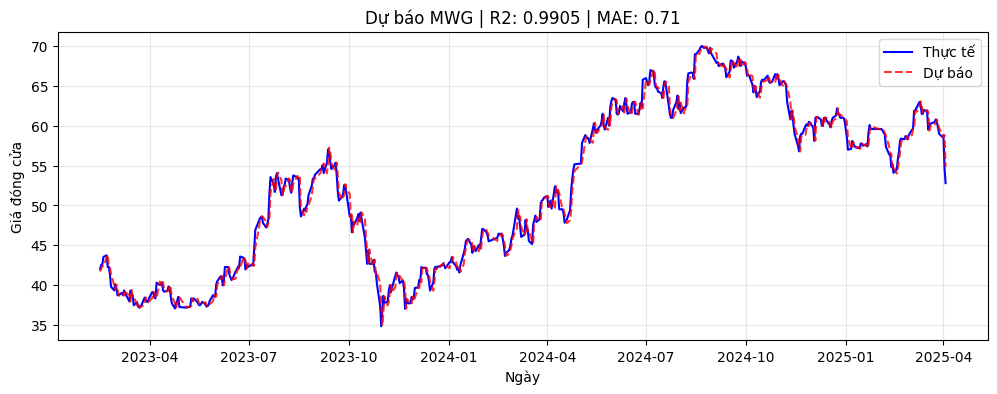

Đã xử lý xong: MWG


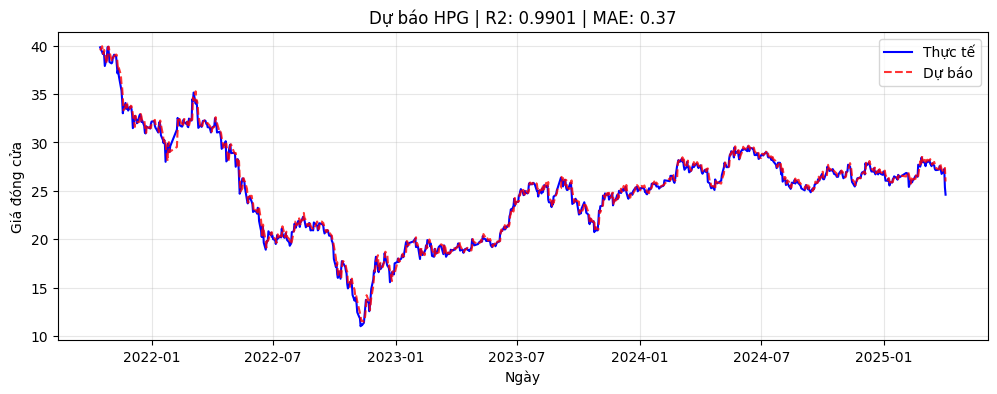

Đã xử lý xong: HPG


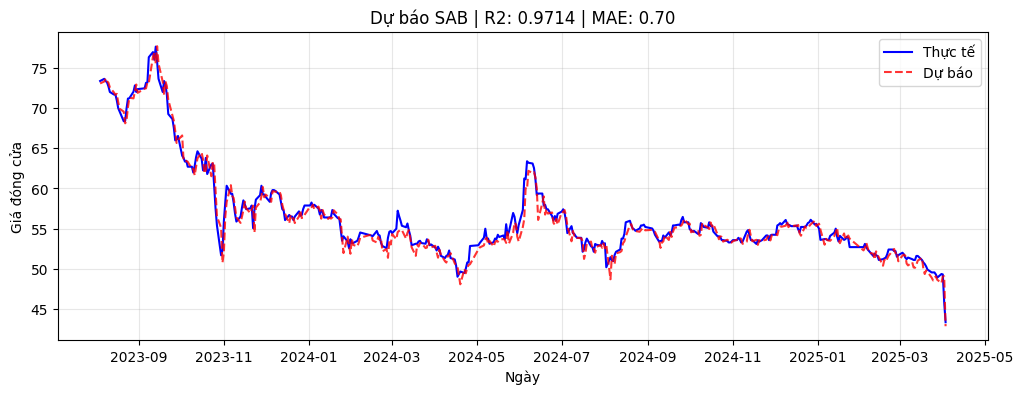

Đã xử lý xong: SAB


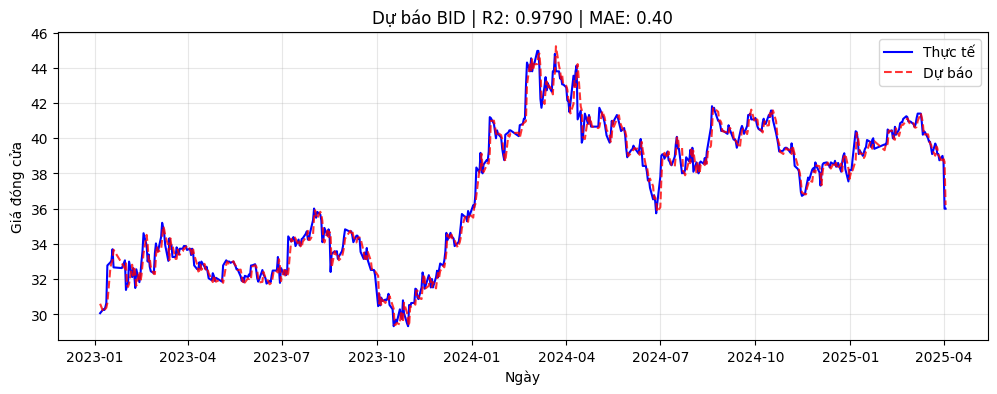

Đã xử lý xong: BID


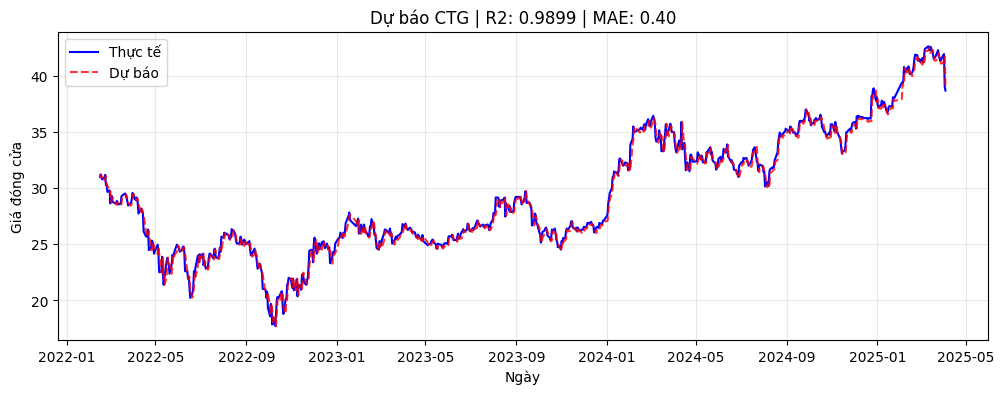

Đã xử lý xong: CTG


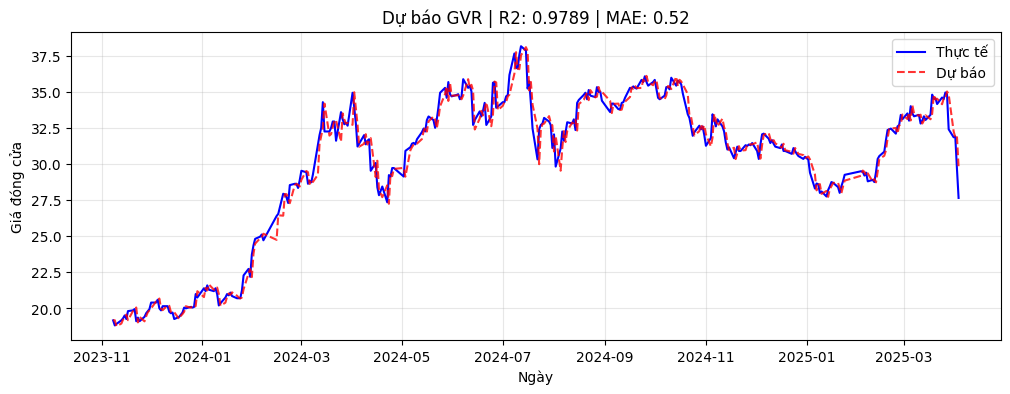

Đã xử lý xong: GVR


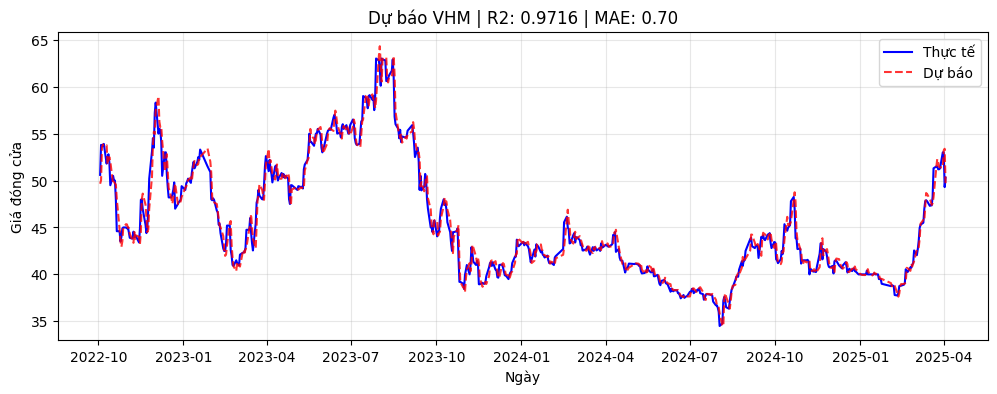

Đã xử lý xong: VHM


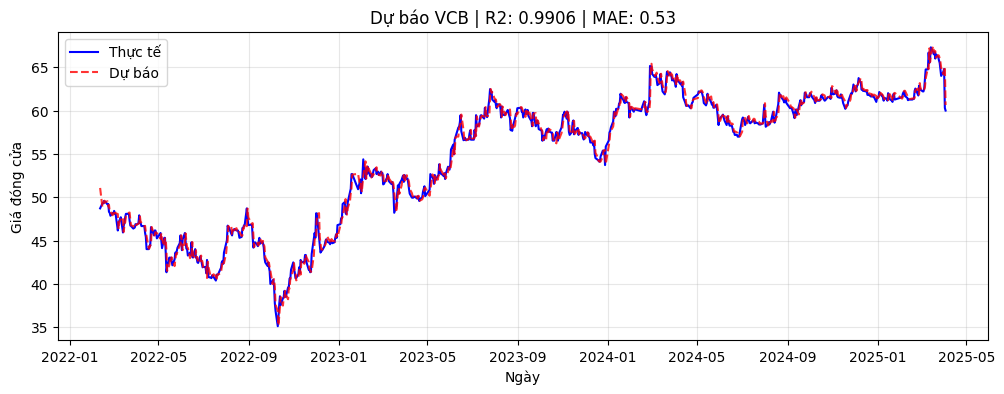

Đã xử lý xong: VCB


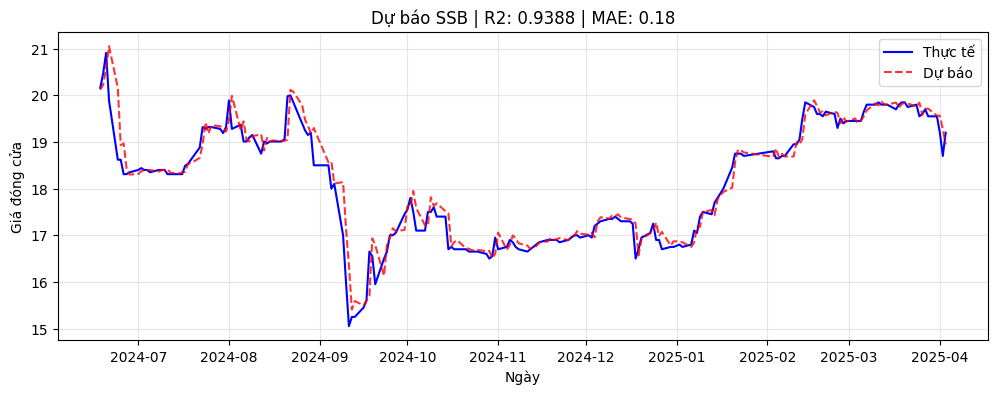

Đã xử lý xong: SSB


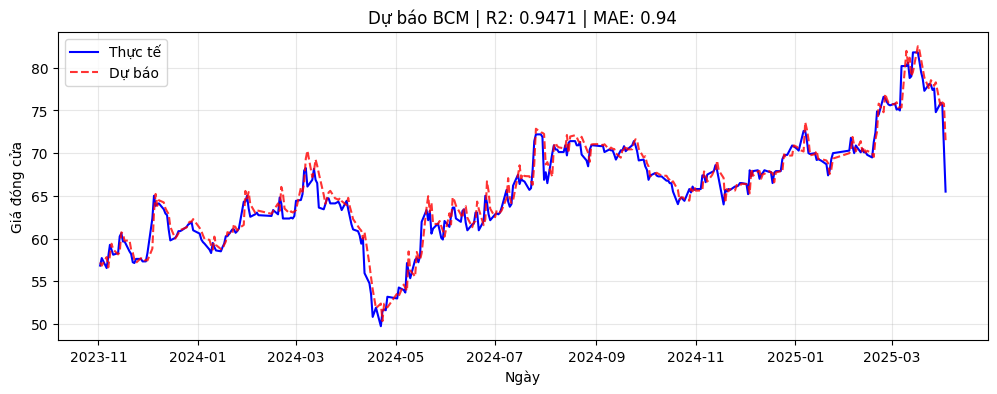

Đã xử lý xong: BCM
Lỗi tại mã VIB: Input X contains infinity or a value too large for dtype('float64').


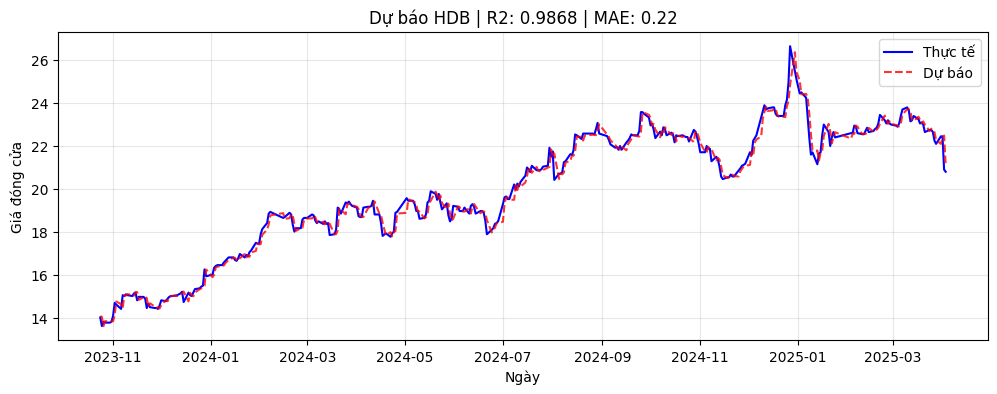

Đã xử lý xong: HDB


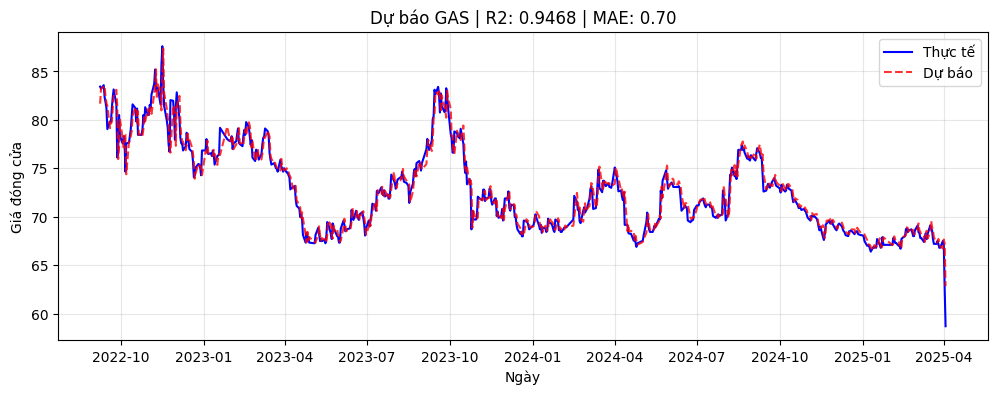

Đã xử lý xong: GAS


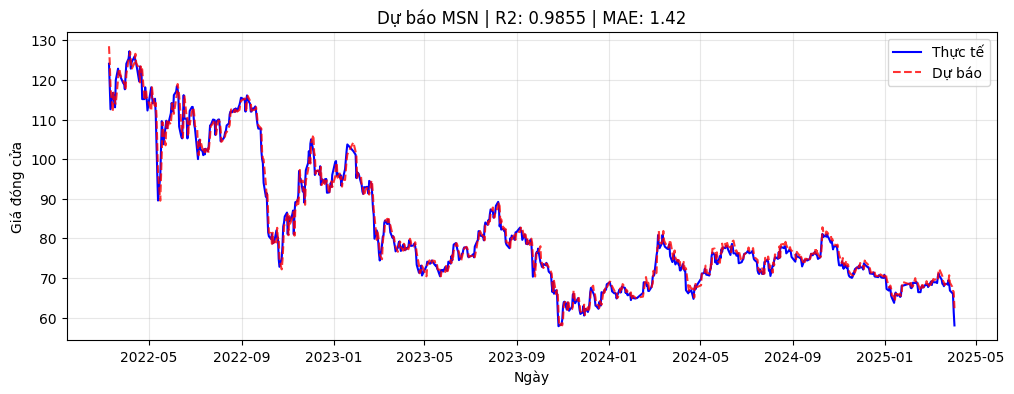

Đã xử lý xong: MSN


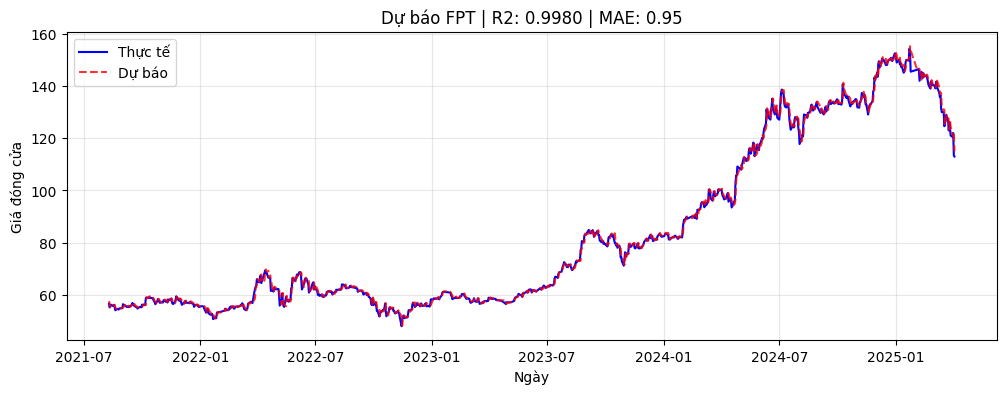

Đã xử lý xong: FPT


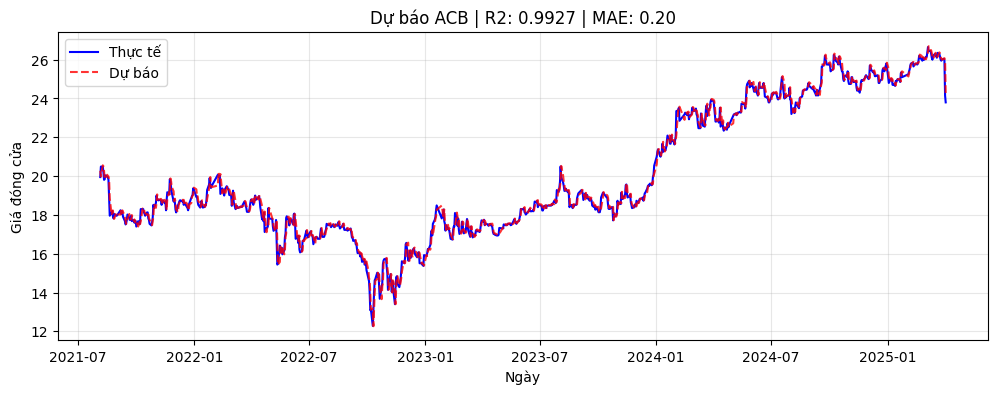

Đã xử lý xong: ACB


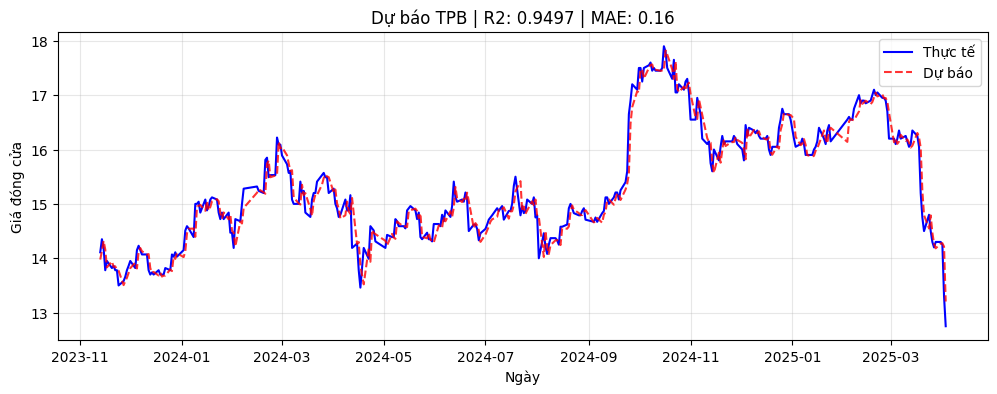

Đã xử lý xong: TPB


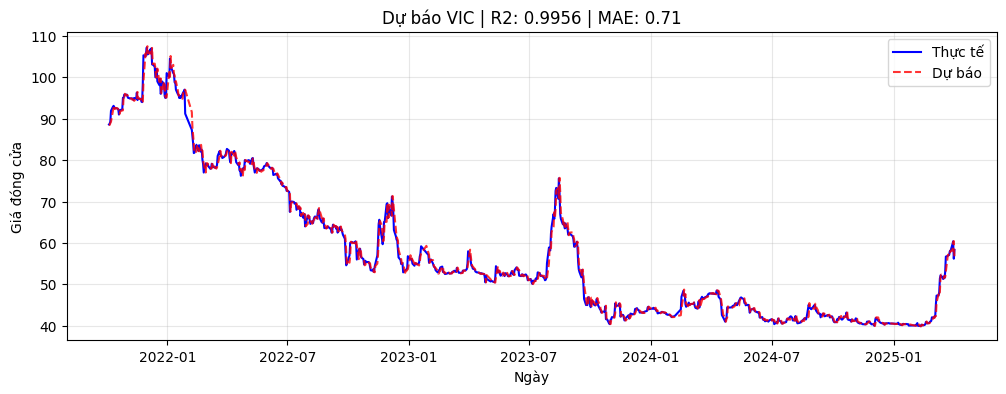

Đã xử lý xong: VIC


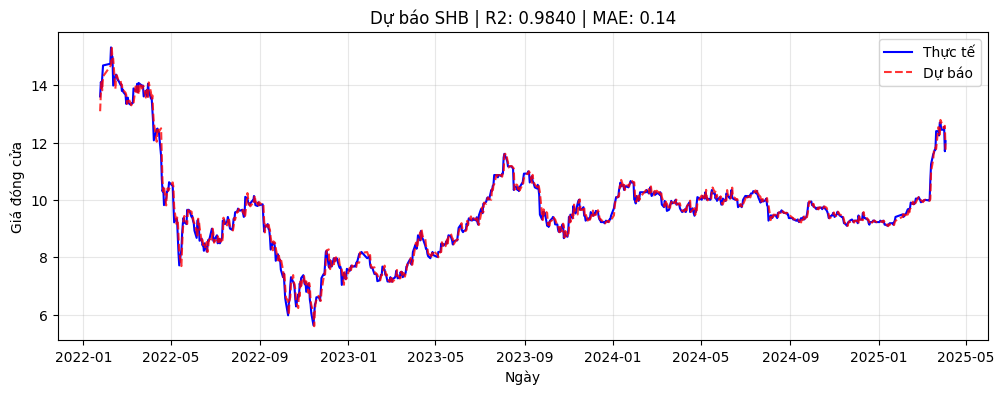

Đã xử lý xong: SHB


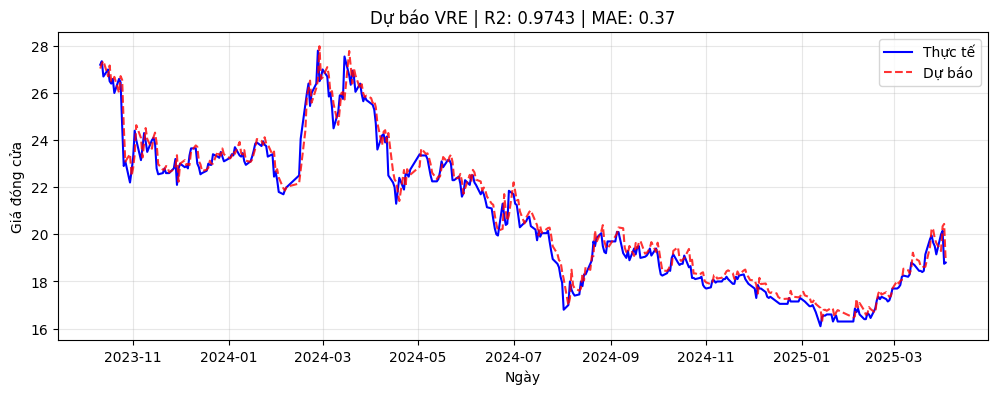

Đã xử lý xong: VRE


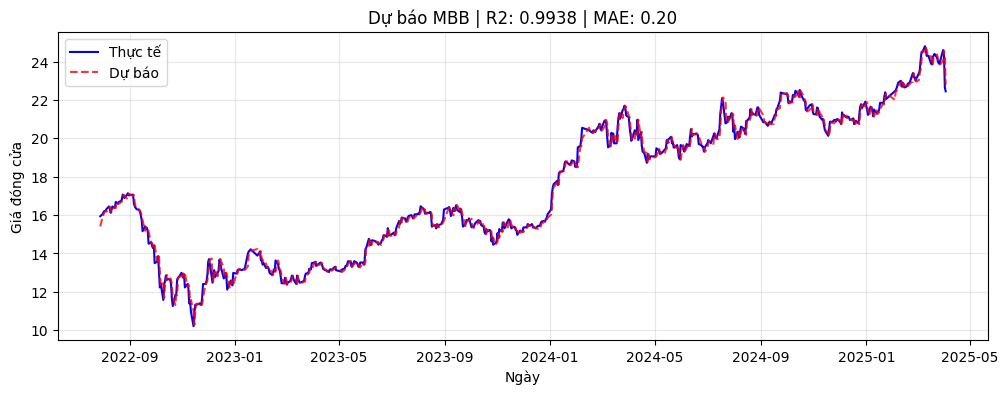

Đã xử lý xong: MBB


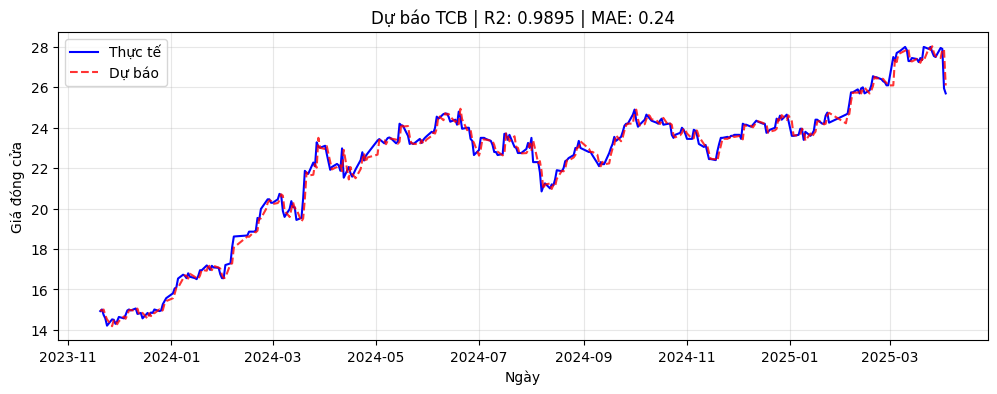

Đã xử lý xong: TCB


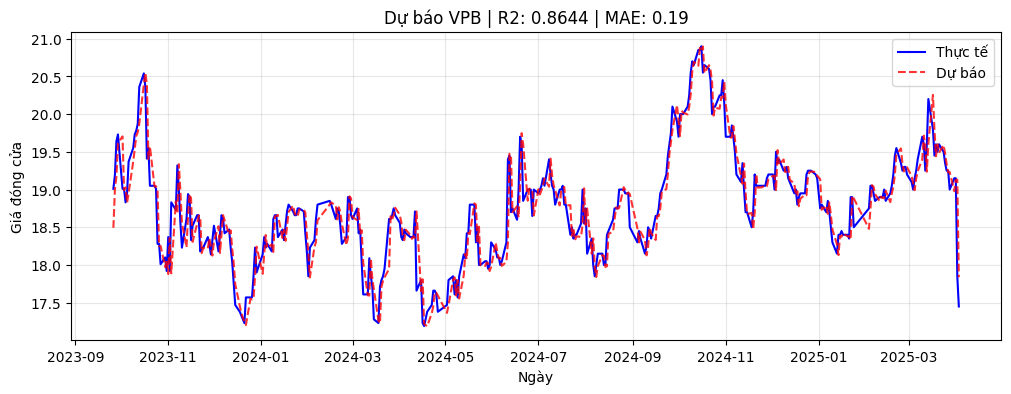

Đã xử lý xong: VPB


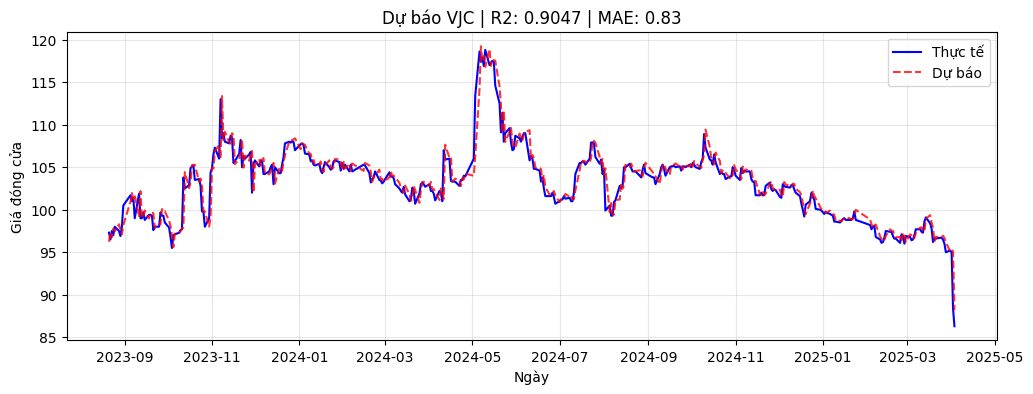

Đã xử lý xong: VJC


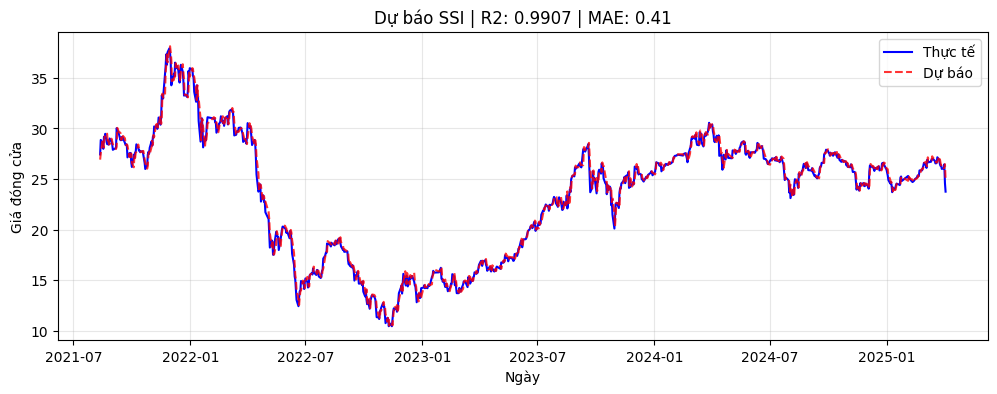

Đã xử lý xong: SSI


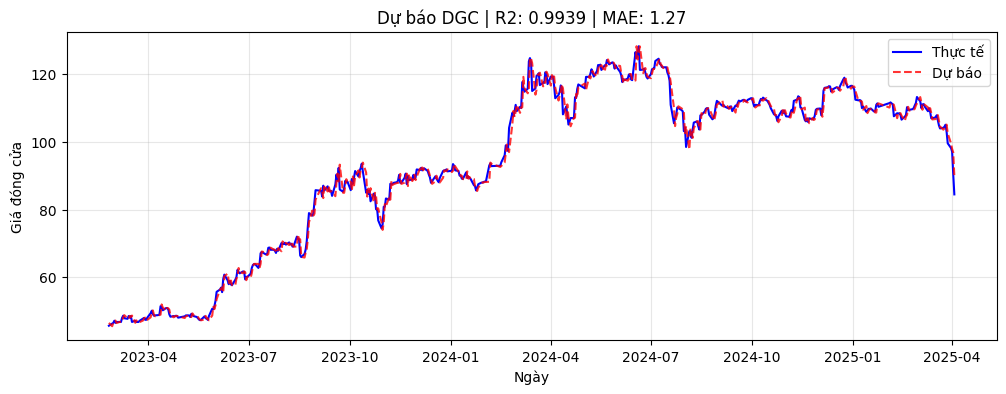

Đã xử lý xong: DGC


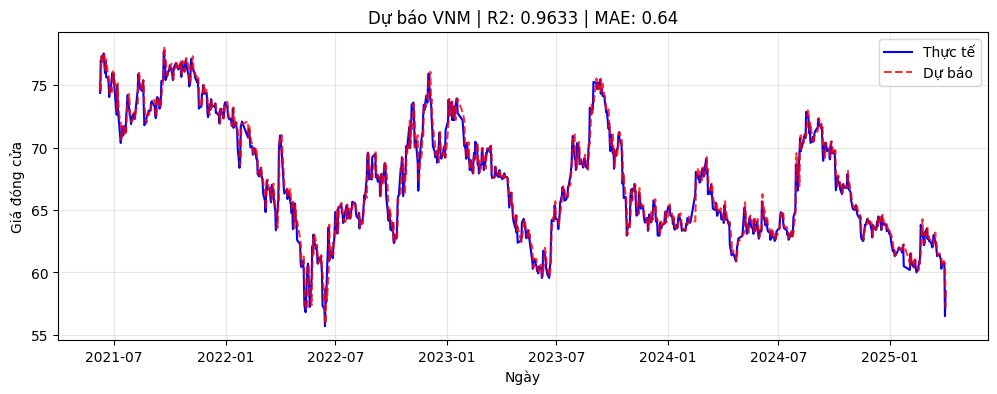

Đã xử lý xong: VNM


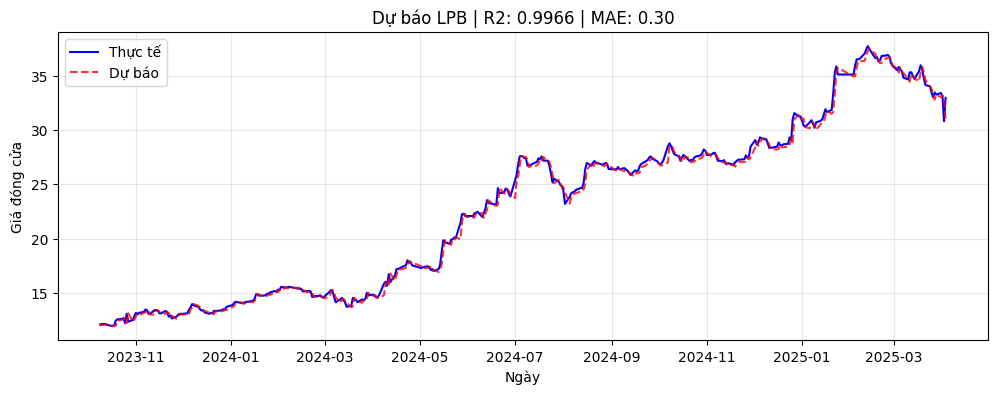

Đã xử lý xong: LPB


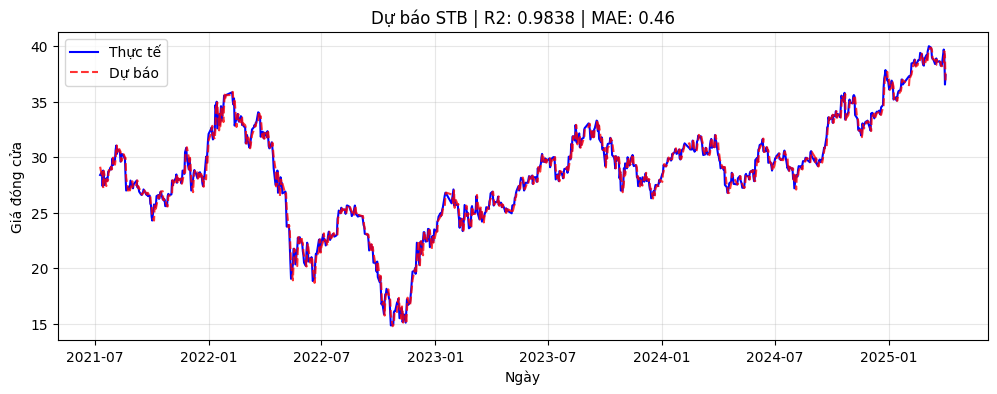

Đã xử lý xong: STB
Lỗi tại mã POW: Input X contains infinity or a value too large for dtype('float64').

BẢNG TỔNG HỢP HIỆU SUẤT
Symbol      MAE       R2
   FPT 0.952403 0.997994
   LPB 0.302316 0.996577
   VIC 0.709512 0.995554
   DGC 1.272510 0.993854
   MBB 0.198742 0.993812
   ACB 0.203093 0.992741
   SSI 0.411638 0.990745
   VCB 0.525100 0.990554
   MWG 0.713708 0.990512
   HPG 0.374523 0.990144
   CTG 0.399068 0.989888
   TCB 0.239295 0.989512
   HDB 0.222663 0.986771
   MSN 1.419649 0.985501
   SHB 0.139312 0.984037
   STB 0.455055 0.983841
   BID 0.396053 0.979014
   GVR 0.515855 0.978868
   VRE 0.365879 0.974334
   VHM 0.700448 0.971629
   SAB 0.700282 0.971408
   VNM 0.642731 0.963334
   TPB 0.163899 0.949689
   BCM 0.943263 0.947131
   GAS 0.699532 0.946803
   SSB 0.180519 0.938784
   VJC 0.833162 0.904684
   VPB 0.188414 0.864400


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Danh sách VN30 (Đã cập nhật)
vn30_2026 = [
    'MWG', 'HPG', 'SAB', 'BID', 'CTG', 'GVR', 'VHM', 'VCB',
    'SSB', 'BCM', 'VIB', 'HDB', 'GAS', 'MSN', 'FPT', 'ACB',
    'TPB', 'VIC', 'SHB', 'VRE', 'MBB', 'TCB', 'VPB', 'VJC',
    'SSI', 'DGC', 'VNM', 'LPB', 'STB', 'POW' # Thay VPL bằng POW hoặc mã phù hợp
]

# ĐƯỜNG DẪN: Hãy đảm bảo bạn đã tạo Shortcut thư mục .vnstock vào MyDrive
folder_path = '/content/drive/MyDrive/.vnstock'

def train_and_plot_all():
    summary_results = []

    # Kiểm tra thư mục đầu vào
    if not os.path.exists(folder_path):
        print(f"Lỗi: Không tìm thấy thư mục {folder_path}")
        return

    for symbol in vn30_2026:
        file_path = os.path.join(folder_path, f"stock_data_{symbol}.csv")

        if os.path.exists(file_path):
            try:
                # 1. Đọc và tiền xử lý dữ liệu
                df = pd.read_csv(file_path)
                df['time'] = pd.to_datetime(df['time'])
                df = df.sort_values('time')

                # 2. Feature Engineering (Tạo thêm biến để Linear Regression hiệu quả hơn)
                df['Volume_Change'] = df['volume'].diff()
                df['MA10'] = df['close'].rolling(window=10).mean()
                df['MA45'] = df['close'].rolling(window=45).mean()
                df['Return'] = df['close'].pct_change()

                # Biến mục tiêu: Giá đóng cửa ngày mai
                df['Target'] = df['close'].shift(-1)

                # Loại bỏ các dòng có giá trị rỗng do tính toán MA và shift
                df = df.dropna()

                # 3. Định nghĩa Features (X) và Target (y)
                features = ['open', 'high', 'low', 'close', 'volume', 'MA10', 'MA45', 'Return']
                X = df[features]
                y = df['Target']

                # 4. Chia dữ liệu Train/Test (8:2) theo thời gian
                split = int(len(X) * 0.8)
                X_train, X_test = X[:split], X[split:]
                y_train, y_test = y[:split], y[split:]
                test_dates = df['time'].iloc[split:]

                # 5. Huấn luyện mô hình Linear Regression
                # Lưu ý: Không có random_state cho LinearRegression
                model = LinearRegression()
                model.fit(X_train, y_train)

                # 6. Dự đoán và Đánh giá
                y_pred = model.predict(X_test)
                mae = mean_absolute_error(y_test, y_pred)
                r2 = r2_score(y_test, y_pred)

                summary_results.append({'Symbol': symbol, 'MAE': mae, 'R2': r2})

                # 7. Vẽ biểu đồ
                plt.figure(figsize=(12, 4))
                plt.plot(test_dates, y_test.values, label='Thực tế', color='blue', linewidth=1.5)
                plt.plot(test_dates, y_pred, label='Dự báo', color='red', linestyle='--', alpha=0.8)
                plt.title(f"Dự báo {symbol} | R2: {r2:.4f} | MAE: {mae:.2f}")
                plt.xlabel("Ngày")
                plt.ylabel("Giá đóng cửa")
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.show()

                print(f"Đã xử lý xong: {symbol}")

            except Exception as e:
                print(f"Lỗi tại mã {symbol}: {e}")
        else:
            print(f"Không tìm thấy file: stock_data_{symbol}.csv")

    # Hiển thị bảng tổng hợp
    if summary_results:
        results_df = pd.DataFrame(summary_results)
        print("\n" + "="*30)
        print("BẢNG TỔNG HỢP HIỆU SUẤT")
        print(results_df.sort_values(by='R2', ascending=False).to_string(index=False))

# Chạy chương trình
train_and_plot_all()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Đang khởi tạo mô hình BiLSTM cho 30 mã VN30...
✅ ACB xong.
✅ BCM xong.
✅ BID xong.
✅ BVH xong.
✅ CTG xong.
✅ FPT xong.
✅ GAS xong.
✅ GVR xong.
✅ HDB xong.
✅ HPG xong.
✅ MBB xong.
✅ MSN xong.
✅ MWG xong.
✅ PLX xong.
✅ POW xong.
✅ SAB xong.
✅ SHB xong.
✅ SSB xong.
✅ SSI xong.
✅ STB xong.
✅ TCB xong.
✅ TPB xong.
✅ VCB xong.
✅ VHM xong.
✅ VIB xong.
✅ VIC xong.
✅ VJC xong.
✅ VNM xong.
✅ VPB xong.
✅ VRE xong.

📊 BẢNG KẾT QUẢ TỔNG HỢP 30 MÃ VN30
   Ticker          MSE        MAE    R2_Score
0     VIB     0.285103   0.440496    0.658673
1     SSB     0.390541   0.503241    0.315095
2     TPB     0.567627   0.598582   -0.541102
3     ACB     1.351779   1.023718   -0.759517
4     SAB     5.293492   1.531093    0.339167
5     POW     5.589402   2.216370   -4.585799
6     TCB     7.498033   2.413934   -0.850040
7     MSN     7.541741   2.139515    0.000787
8     BCM   

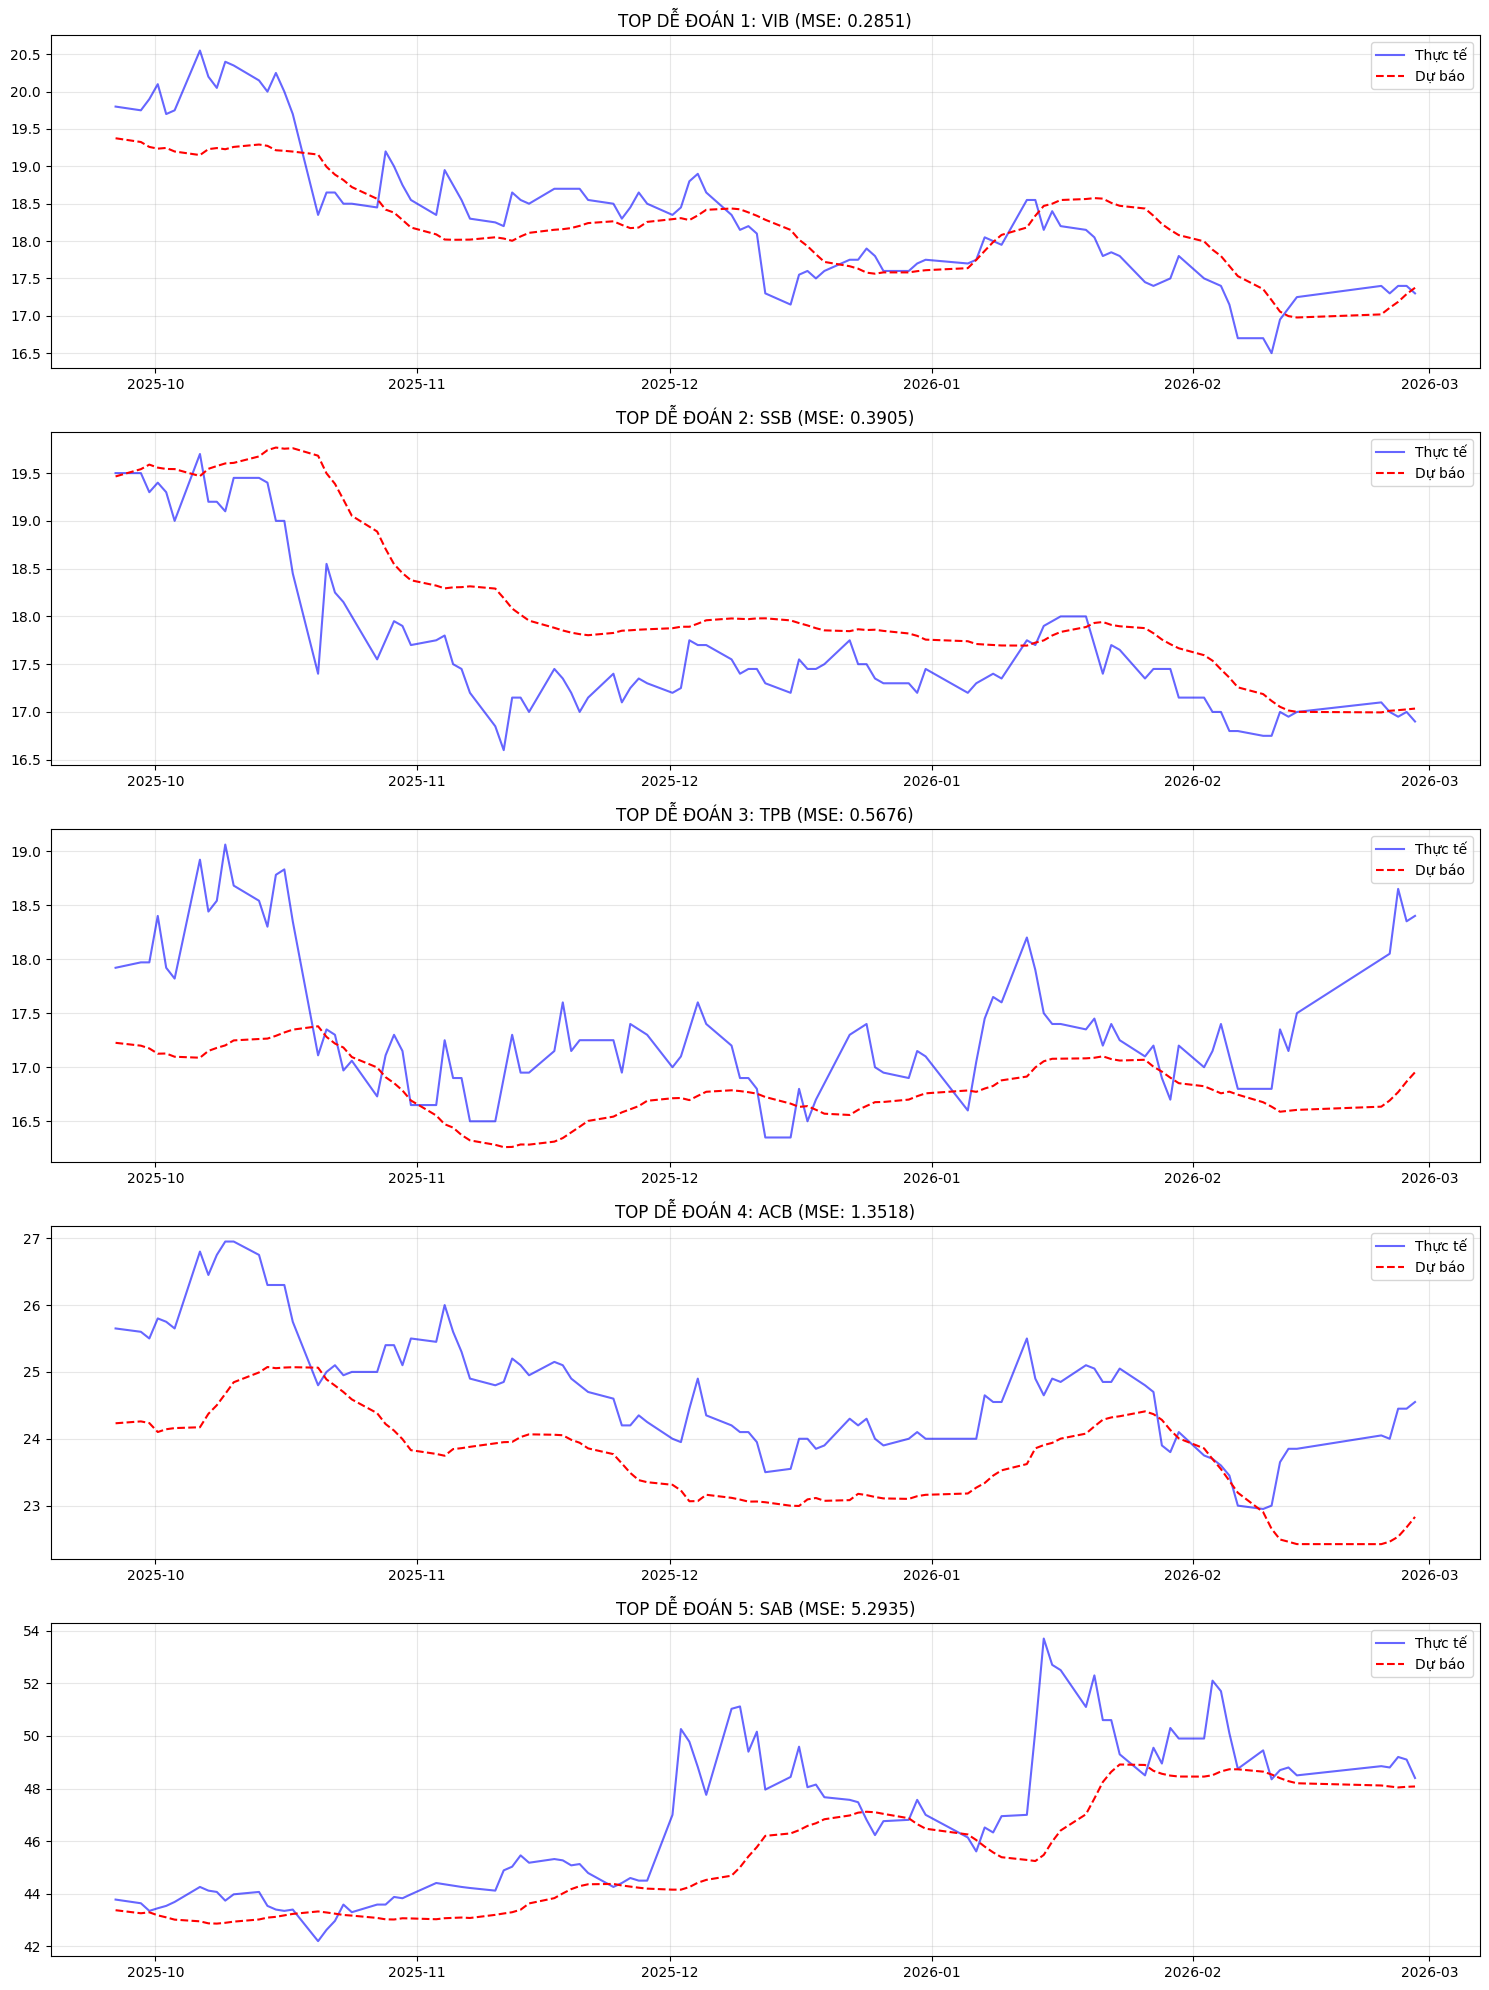


📉 ĐANG VẼ BIỂU ĐỒ 5 MÃ KHÓ DỰ ĐOÁN NHẤT...


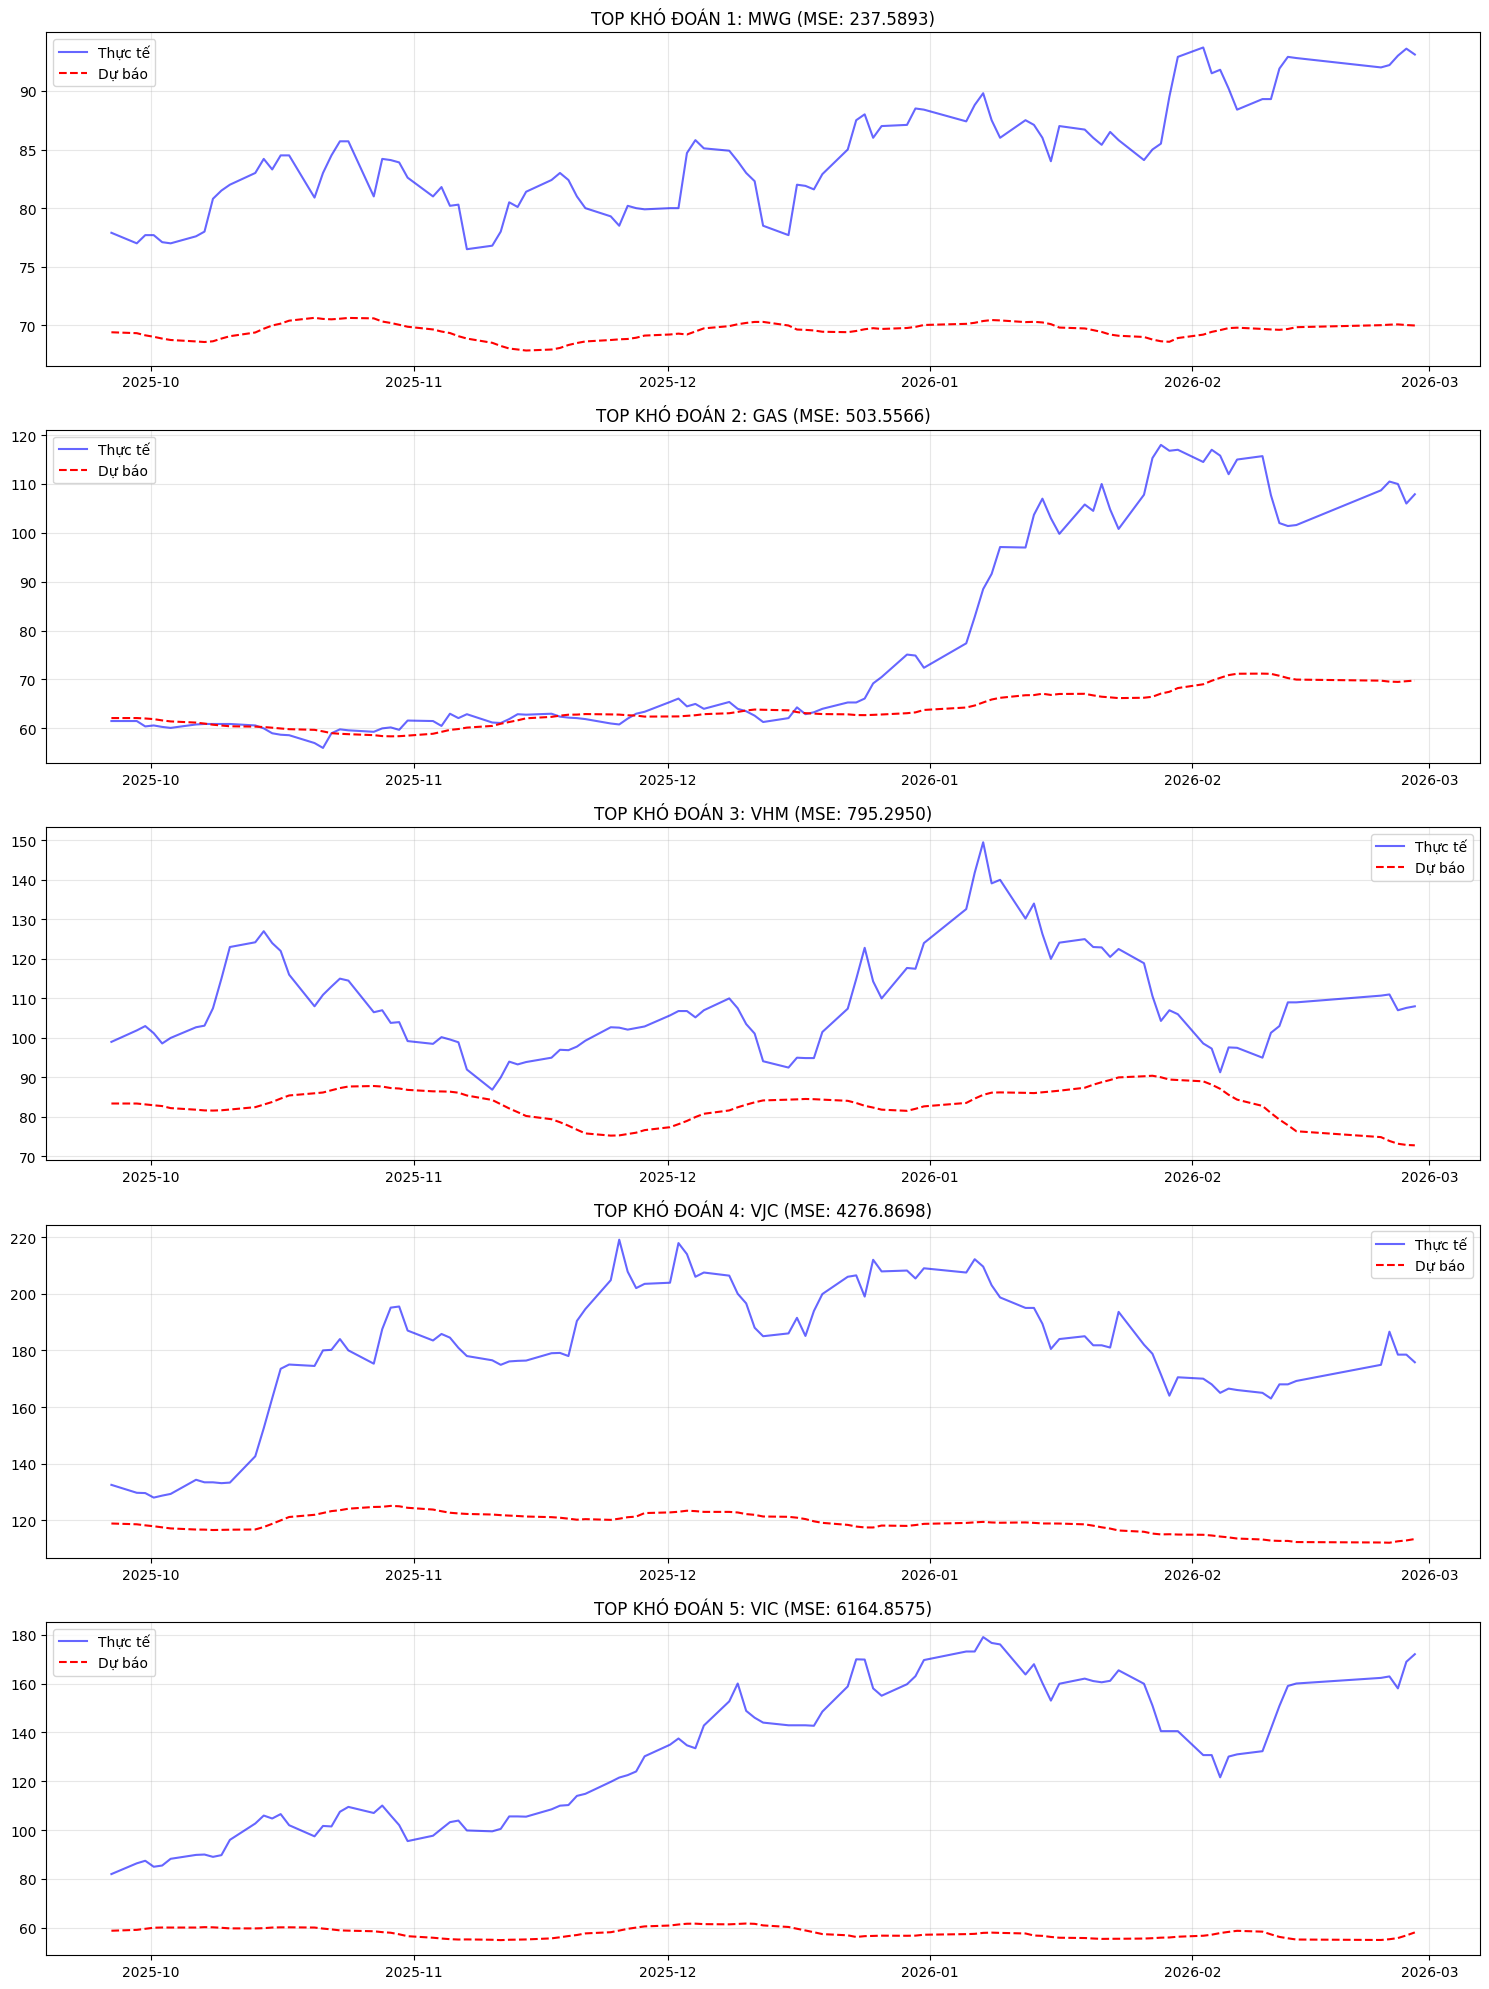

In [9]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive
import warnings

# Tắt cảnh báo rườm rà
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# 0. KẾT NỐI DRIVE
drive.mount('/content/drive')

# 1. CẤU HÌNH
vn30_2026 = ["ACB", "BCM", "BID", "BVH", "CTG", "FPT", "GAS", "GVR", "HDB", "HPG",
             "MBB", "MSN", "MWG", "PLX", "POW", "SAB", "SHB", "SSB", "SSI", "STB",
             "TCB", "TPB", "VCB", "VHM", "VIB", "VIC", "VJC", "VNM", "VPB", "VRE"]

folder_path = '/content/drive/MyDrive/VN30_Raw_Data'
window_size = 10
features = ['close', 'volume', 'MB', 'BB_Upper_2', 'BB_Lower_2', 'BB_Upper_3', 'BB_Lower_3',
            'BB_Upper_4', 'BB_Lower_4', 'Ichi_Base_65', 'Ichi_Base_129', 'Ichi_Base_172',
            'Ichi_Base_257', 'Ichi_Conv', 'Ichi_Chikou', 'RSI', 'MACD', 'Signal_Line', 'MACD_Hist', 'PSAR']

# 2. HÀM TÍNH TOÁN KỸ THUẬT
def calculate_psar(df, af=0.02, max_af=0.2):
    high, low, close = df['high'].values, df['low'].values, df['close'].values
    psar, bull, af_val = close.copy(), True, af
    ep, hp, lp = low[0], high[0], low[0]
    for i in range(2, len(df)):
        psar[i] = psar[i-1] + af_val * ((hp if bull else lp) - psar[i-1])
        reverse = False
        if bull and low[i] < psar[i]: bull, reverse, psar[i], lp, af_val = False, True, hp, low[i], af
        elif not bull and high[i] > psar[i]: bull, reverse, psar[i], hp, af_val = True, True, lp, high[i], af
        if not reverse:
            if bull:
                if high[i] > hp: hp, af_val = high[i], min(af_val + af, max_af)
                psar[i] = min(psar[i], low[i-1], low[i-2])
            else:
                if low[i] < lp: lp, af_val = low[i], min(af_val + af, max_af)
                psar[i] = max(psar[i], high[i-1], high[i-2])
    return psar

def apply_indicators(df):
    df['MB'] = df['close'].rolling(14).mean()
    std = df['close'].rolling(14).std()
    for k in [2, 3, 4]:
        df[f'BB_Upper_{k}'], df[f'BB_Lower_{k}'] = df['MB'] + (k * std), df['MB'] - (k * std)
    for k in [65, 129, 172, 257]:
        df[f'Ichi_Base_{k}'] = (df['high'].rolling(k).max() + df['low'].rolling(k).min()) / 2
    df['Ichi_Conv'], df['Ichi_Chikou'] = (df['high'] + df['low']) / 2, df['close']
    delta = df['close'].diff()
    gain, loss = (delta.where(delta > 0, 0)).rolling(14).mean(), (-delta.where(delta < 0, 0)).rolling(14).mean()
    df['RSI'] = 100 - (100 / (1 + gain/loss))
    exp1, exp2 = df['close'].ewm(span=12).mean(), df['close'].ewm(span=26).mean()
    df['MACD'] = exp1 - exp2
    df['Signal_Line'] = df['MACD'].ewm(span=9).mean()
    df['MACD_Hist'] = df['MACD'] - df['Signal_Line']
    df['PSAR'] = calculate_psar(df)
    return df.dropna().reset_index(drop=True)

def create_sequences(data, target, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)]), y.append(target[i + window_size])
    return np.array(X), np.array(y)

# 4. CHƯƠNG TRÌNH CHÍNH
def train_and_report_full():
    summary_data, plots = [], {}
    print("🚀 Đang khởi tạo mô hình BiLSTM cho 30 mã VN30...")

    for ticker in vn30_2026:
        file_path = os.path.join(folder_path, f"{ticker}_price_2023_2026.csv")
        if not os.path.exists(file_path): continue

        try:
            # Tiền xử lý
            df = pd.read_csv(file_path)
            df.columns = [c.lower() for c in df.columns]
            df['time'] = pd.to_datetime(df.get('time', df.get('date')))
            df = df.sort_values('time').reset_index(drop=True)
            df = apply_indicators(df)

            split = int(len(df) * 0.8)
            scaler_X, scaler_y = MinMaxScaler(), MinMaxScaler()
            scaler_X.fit(df.iloc[:split][features])
            scaler_y.fit(df.iloc[:split][['close']])

            X_s, y_s = scaler_X.transform(df[features]), scaler_y.transform(df[['close']])
            X_seq, y_seq = create_sequences(X_s, y_s, window_size)

            s_split = int(len(X_seq) * 0.8)
            X_train, X_test = X_seq[:s_split], X_seq[s_split:]
            y_train, y_test = y_seq[:s_split], y_seq[s_split:]

            # Model
            model = Sequential([
                Input(shape=(window_size, len(features))),
                Bidirectional(LSTM(64, return_sequences=True)),
                Dropout(0.2),
                BatchNormalization(),
                Bidirectional(LSTM(32)),
                Dropout(0.2),
                Dense(16, activation='relu'),
                Dense(1)
            ])
            model.compile(optimizer='adam', loss='mse')
            model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.1,
                      callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)], verbose=0)

            # Dự báo
            y_p = scaler_y.inverse_transform(model.predict(X_test, verbose=0))
            y_r = scaler_y.inverse_transform(y_test)

            # Tính Metrics
            mse = mean_squared_error(y_r, y_p)
            mae = mean_absolute_error(y_r, y_p)
            r2 = r2_score(y_r, y_p)

            summary_data.append({'Ticker': ticker, 'MSE': mse, 'MAE': mae, 'R2_Score': r2})
            plots[ticker] = {'time': df['time'].iloc[s_split+window_size:], 'real': y_r, 'pred': y_p}
            print(f"✅ {ticker} xong.")

        except Exception as e: print(f"❌ Lỗi {ticker}: {e}")

    # XỬ LÝ KẾT QUẢ
    if summary_data:
        full_df = pd.DataFrame(summary_data).sort_values('MSE').reset_index(drop=True)

        print("\n" + "="*60)
        print("📊 BẢNG KẾT QUẢ TỔNG HỢP 30 MÃ VN30")
        print("="*60)
        print(full_df.to_string())

        # Insight cho Thành
        best_5 = full_df.head(5)
        worst_5 = full_df.tail(5)

        print("\n" + "="*60)
        print("💡 KEY INSIGHTS CHO REPORT")
        print(f"- Loại Model: BiLSTM (Học sâu hai chiều)")
        print(f"- Tổng số mã: {len(full_df)}")
        print(f"- Avg MSE toàn hệ thống: {full_df['MSE'].mean():.4f}")
        print(f"- Mã dễ dự báo nhất: {best_5['Ticker'].tolist()}")
        print(f"- Mã biến động khó lường nhất: {worst_5['Ticker'].tolist()}")
        print("="*60)

        # VẼ BIỂU ĐỒ TOP 5 DỄ
        print("\n📈 ĐANG VẼ BIỂU ĐỒ 5 MÃ DỄ DỰ ĐOÁN NHẤT...")
        fig, axes = plt.subplots(5, 1, figsize=(15, 20))
        for i, ticker in enumerate(best_5['Ticker']):
            axes[i].plot(plots[ticker]['time'], plots[ticker]['real'], label='Thực tế', color='blue', alpha=0.6)
            axes[i].plot(plots[ticker]['time'], plots[ticker]['pred'], label='Dự báo', color='red', linestyle='--')
            axes[i].set_title(f"TOP DỄ ĐOÁN {i+1}: {ticker} (MSE: {best_5.iloc[i]['MSE']:.4f})")
            axes[i].legend(); axes[i].grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

        # VẼ BIỂU ĐỒ TOP 5 KHÓ
        print("\n📉 ĐANG VẼ BIỂU ĐỒ 5 MÃ KHÓ DỰ ĐOÁN NHẤT...")
        fig, axes = plt.subplots(5, 1, figsize=(15, 20))
        for i, ticker in enumerate(worst_5['Ticker']):
            axes[i].plot(plots[ticker]['time'], plots[ticker]['real'], label='Thực tế', color='blue', alpha=0.6)
            axes[i].plot(plots[ticker]['time'], plots[ticker]['pred'], label='Dự báo', color='red', linestyle='--')
            axes[i].set_title(f"TOP KHÓ ĐOÁN {i+1}: {ticker} (MSE: {worst_5.iloc[i]['MSE']:.4f})")
            axes[i].legend(); axes[i].grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

train_and_report_full()